<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_046_adaboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 46/365 — Boosting with AdaBoost
## What if each new model focused on the mistakes made by the previous ones?

Yesterday we learned **Bagging**: train many models independently and combine their predictions.

Today we learn a different ensemble idea:

**Boosting**

Boosting builds models **sequentially**.

Each new model focuses more on examples that earlier models got wrong.

A classic algorithm for this is **AdaBoost (Adaptive Boosting)**.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score


## 1. Load a real dataset


In [2]:
data = load_breast_cancer(as_frame=True)

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Dataset shape:", X.shape)
print("Classes:", data.target_names)


Dataset shape: (569, 30)
Classes: ['malignant' 'benign']


## 2. Start with a weak learner

AdaBoost often uses very small Decision Trees called **decision stumps**.

A stump has:

`max_depth = 1`

By itself, it is intentionally simple.


In [3]:
stump = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

stump.fit(X_train, y_train)

stump_train = accuracy_score(y_train, stump.predict(X_train))
stump_test = accuracy_score(y_test, stump.predict(X_test))

print("Decision Stump Train Accuracy:", round(stump_train, 3))
print("Decision Stump Test Accuracy:", round(stump_test, 3))


Decision Stump Train Accuracy: 0.923
Decision Stump Test Accuracy: 0.923


## 3. Combine many weak learners with AdaBoost

AdaBoost trains weak learners one after another.

After each round, it puts more emphasis on examples that were misclassified.

The final prediction combines the weak learners using a weighted vote.


In [4]:
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

ada.fit(X_train, y_train)

ada_train = accuracy_score(y_train, ada.predict(X_train))
ada_test = accuracy_score(y_test, ada.predict(X_test))

print("AdaBoost Train Accuracy:", round(ada_train, 3))
print("AdaBoost Test Accuracy:", round(ada_test, 3))


AdaBoost Train Accuracy: 1.0
AdaBoost Test Accuracy: 0.965


## 4. Compare one weak learner with AdaBoost


,Model,Training Accuracy,Test Accuracy
0,Decision Stump,0.923,0.923
1,AdaBoost,1.000,0.965


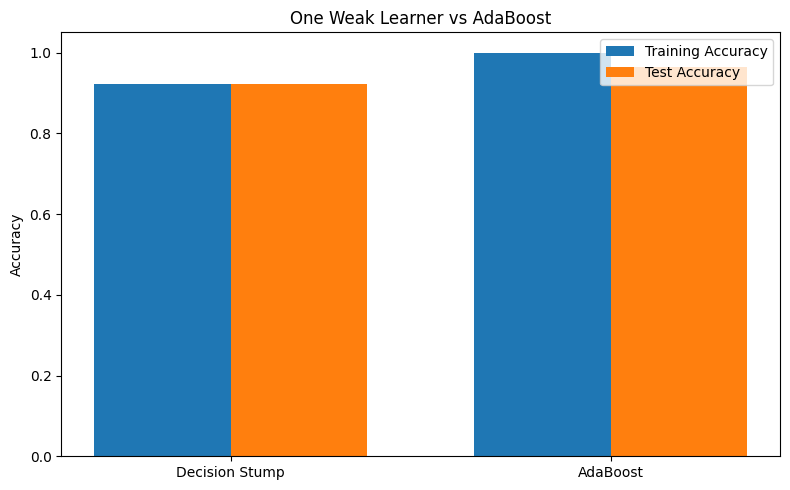

In [5]:
comparison = pd.DataFrame({
    "Model": ["Decision Stump", "AdaBoost"],
    "Training Accuracy": [stump_train, ada_train],
    "Test Accuracy": [stump_test, ada_test]
})

display(comparison.round(3))

x = np.arange(len(comparison))

plt.figure(figsize=(8,5))
plt.bar(x - 0.18, comparison["Training Accuracy"], width=0.36, label="Training Accuracy")
plt.bar(x + 0.18, comparison["Test Accuracy"], width=0.36, label="Test Accuracy")
plt.xticks(x, comparison["Model"])
plt.ylabel("Accuracy")
plt.title("One Weak Learner vs AdaBoost")
plt.legend()
plt.tight_layout()
plt.show()


## 5. What happens as we add more boosting rounds?

`n_estimators` controls how many weak learners are added.


,Number of Weak Learners,Test Accuracy
0,1,0.923
1,5,0.944
2,10,0.951
3,25,0.958
4,50,0.958
5,100,0.965
6,200,0.958


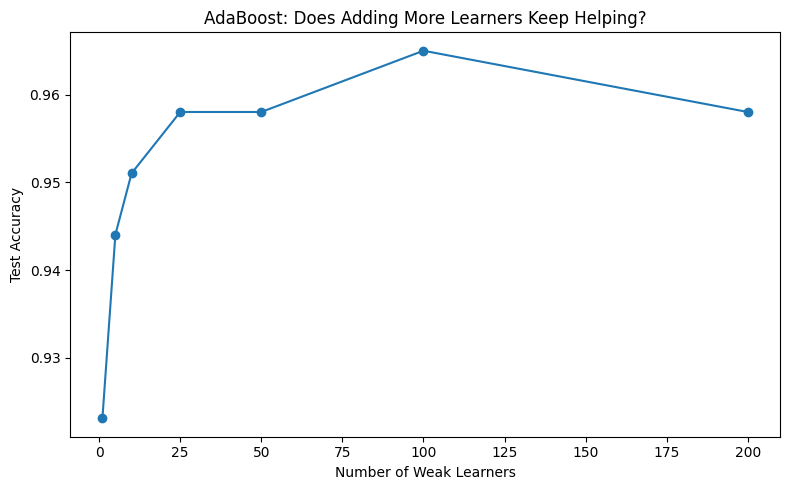

In [6]:
estimator_counts = [1, 5, 10, 25, 50, 100, 200]
scores = []

for count in estimator_counts:
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=count,
        learning_rate=0.5,
        random_state=42
    )

    model.fit(X_train, y_train)
    scores.append(
        accuracy_score(
            y_test,
            model.predict(X_test)
        )
    )

results = pd.DataFrame({
    "Number of Weak Learners": estimator_counts,
    "Test Accuracy": scores
})

display(results.round(3))

plt.figure(figsize=(8,5))
plt.plot(
    results["Number of Weak Learners"],
    results["Test Accuracy"],
    marker="o"
)
plt.xlabel("Number of Weak Learners")
plt.ylabel("Test Accuracy")
plt.title("AdaBoost: Does Adding More Learners Keep Helping?")
plt.tight_layout()
plt.show()


## 6. Bagging vs Boosting

### Bagging
- models are trained independently
- bootstrap samples create diversity
- predictions are aggregated
- often used to reduce variance

### Boosting
- models are trained sequentially
- later learners focus more on earlier mistakes
- predictions are combined with weights
- many weak learners can form a strong learner


## Enterprise intuition

Imagine a fraud-detection system.

The first weak learner may catch obvious fraud based on transaction amount.

But it may miss suspicious transactions with normal amounts.

The next learner gives more attention to the cases the earlier ensemble handled poorly and may pick up another pattern, such as unusual device behavior.

A later learner may focus on another difficult group.

This sequential correction idea can be useful in:

- fraud detection
- credit-risk classification
- customer churn
- claims triage
- risk scoring


## Important limitation

Because AdaBoost keeps increasing emphasis on difficult examples, noisy labels and true outliers can sometimes receive too much attention.

That is why validation and data quality still matter.


## What does this teach?

- Boosting combines many weak learners.
- AdaBoost trains them sequentially.
- Misclassified observations receive more attention in later rounds.
- Individual learners can be weak, but their weighted combination can be stronger.
- `n_estimators` and `learning_rate` are important hyperparameters.
- More boosting rounds do not guarantee endless improvement.

> **Bagging asks many models independently. Boosting asks later models to focus on mistakes the ensemble is still making.**


## References

- https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html
- https://scikit-learn.org/stable/modules/ensemble.html#adaboost
- https://www.sciencedirect.com/science/article/pii/S002200009791504X
- https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html
